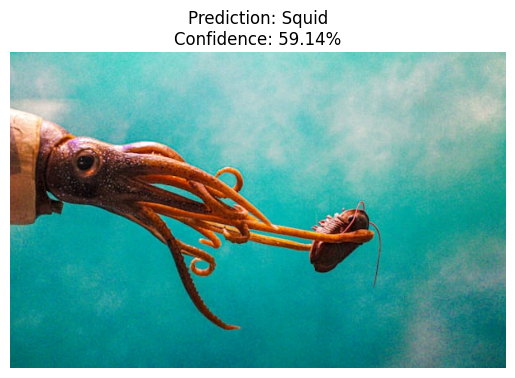

✅ Predicted: Squid (59.14%)


In [13]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

# 1. SETUP MODEL (Ensure this matches your training)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 9) 
# Make sure your .pth file is in the same folder as this script
model.load_state_dict(torch.load('marine_model.pth', map_location=device))
model.to(device)
model.eval()

class_names = ['Fish', 'Goldfish', 'Harbor seal', 'Jellyfish', 'Lobster', 'Oyster', 'Sea turtle', 'Squid', 'Starfish']

# 2. THE PREDICTION FUNCTION
def predict_from_url(url):
    try:
        # A 'User-Agent' makes the website think a person is visiting, not a bot
        headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
        }
        
        response = requests.get(url, headers=headers, timeout=10)
        
        # Check if the request was successful
        if response.status_code != 200:
            print(f"❌ Error: Website returned status code {response.status_code}. It might be blocking the request.")
            return

        img = Image.open(BytesIO(response.content)).convert('RGB')
        
        # Transform for ResNet
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        
        img_tensor = transform(img).unsqueeze(0).to(device)
        
        # Inference
        with torch.no_grad():
            output = model(img_tensor)
            _, predicted = torch.max(output, 1)
            confidence = torch.nn.functional.softmax(output, dim=1)[0][predicted[0]].item() * 100
            
        # Display Result
        plt.imshow(img)
        plt.title(f"Prediction: {class_names[predicted[0]]}\nConfidence: {confidence:.2f}%")
        plt.axis('off')
        plt.show()
        
        print(f"✅ Predicted: {class_names[predicted[0]]} ({confidence:.2f}%)")

    except Exception as e:
        print(f"❌ Error: {e}")

# 3. USE A DIRECT LINK
# Note: Pixabay links often require the direct CDN link. 
# Try this link which is a direct JPEG address:
test_url = "https://images.unsplash.com/photo-1711239071120-8b1b4068d4b3?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8Mnx8c3F1aWR8ZW58MHx8MHx8fDA%3D"
predict_from_url(test_url)

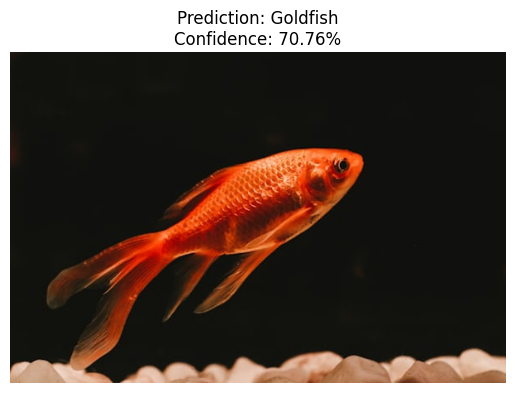

✅ Predicted: Goldfish (70.76%)


In [15]:
test_url1 = "https://images.unsplash.com/photo-1625369708811-65ebfc5ca632?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8M3x8Z29sZGZpc2h8ZW58MHx8MHx8fDA%3D"
predict_from_url(test_url1)

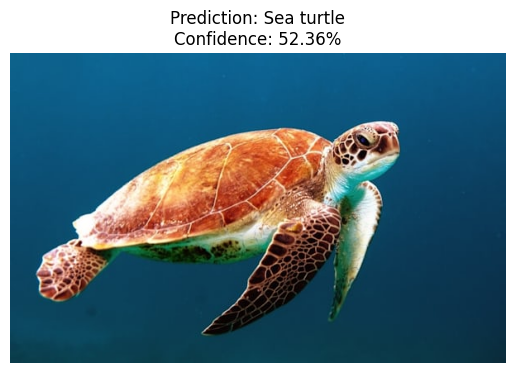

✅ Predicted: Sea turtle (52.36%)


In [16]:
test_url2 = "https://images.unsplash.com/photo-1437622368342-7a3d73a34c8f?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8N3x8ZmlzaHxlbnwwfHwwfHx8MA%3D%3D"
predict_from_url(test_url2)

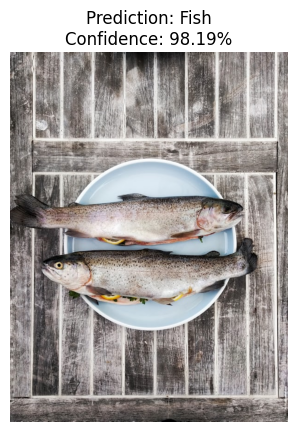

✅ Predicted: Fish (98.19%)


In [17]:
test_url3 = "https://images.unsplash.com/photo-1510130387422-82bed34b37e9?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTZ8fGZpc2h8ZW58MHx8MHx8fDA%3D"
predict_from_url(test_url3)

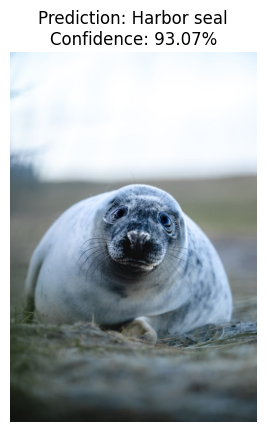

✅ Predicted: Harbor seal (93.07%)


In [19]:
test_url4 = "https://plus.unsplash.com/premium_photo-1672743560623-9f65c58273fb?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8NXx8aGFyYm9yJTIwc2VhbHxlbnwwfHwwfHx8MA%3D%3D"
predict_from_url(test_url4)

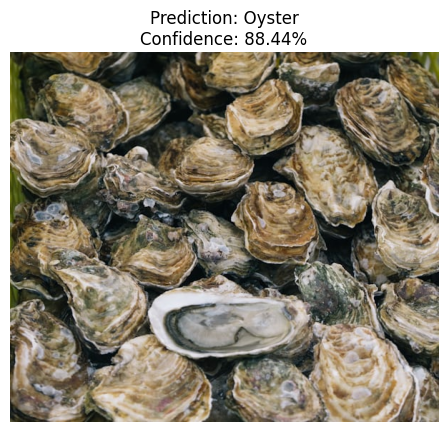

✅ Predicted: Oyster (88.44%)


In [18]:
test_url5 = "https://images.unsplash.com/photo-1578882422378-9ed72be08b5e?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8NHx8b3lzdGVyfGVufDB8fDB8fHww"
predict_from_url(test_url5)

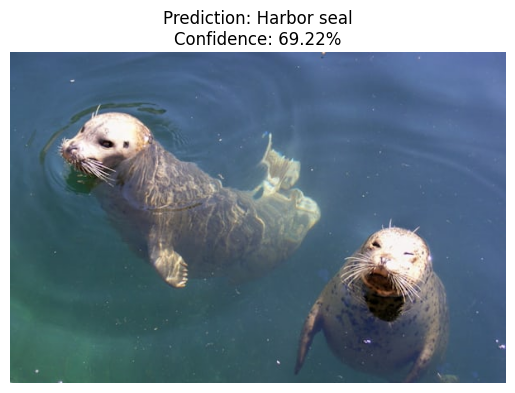

✅ Predicted: Harbor seal (69.22%)


In [20]:
test_url6 = "https://images.unsplash.com/photo-1675121170912-ac372b88774e?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTZ8fGhhcmJvciUyMHNlYWx8ZW58MHx8MHx8fDA%3D"
predict_from_url(test_url6)